# SAM2 Box-Prompt → YOLOv8-seg

ทดลองใช้ **SAM2** แปลง bounding box annotation ของ COCO ให้เป็น segmentation mask  
จากนั้นนำ mask ที่ได้ไป train และ evaluate **YOLOv8-seg**

```
COCO bbox (GT)  →  SAM2 (box prompt)  →  mask + class  →  YOLOv8-seg
```

| | |
|---|---|
| Dataset | COCO (subset) |
| SAM2 prompt | GT bounding box |
| Mask selection | highest IoU vs GT bbox |
| Train / Val / Test | SAM2-generated masks ทุก split |

## Step 1 · ตรวจสอบ GPU และติดตั้ง Dependencies

In [1]:
import torch

if torch.cuda.is_available():
    print(f'✅ GPU: {torch.cuda.get_device_name(0)}'
          f'  |  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  ไม่พบ GPU — Runtime → Change runtime type → GPU')

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

✅ GPU: NVIDIA L4  |  VRAM: 23.7 GB
Device: cuda:0


In [2]:
!pip install ultralytics fiftyone --quiet
!pip install -q 'git+https://github.com/facebookresearch/sam2.git'

import os; os.makedirs('checkpoints', exist_ok=True)
!wget -qc -O checkpoints/sam2.1_hiera_large.pt \
    https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
print('✅ ติดตั้งเสร็จสิ้น')

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 69.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 120.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.5/323.5 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.9/112.9 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 165.1 MB/s eta 0

## Step 2 · Config

In [2]:
import json, random, shutil, cv2, yaml
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from pycocotools.coco import COCO
from pycocotools import mask as maskUtils

# ── ปรับค่าตรงนี้ ────────────────────────────────────────
SEED         = 42
MAX_SAMPLES  = 2000          # จำนวนภาพที่โหลดจาก COCO
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15          # test = ส่วนที่เหลือ

DATA_ROOT    = Path('dataset')
SAM2_CFG     = 'configs/sam2.1/sam2.1_hiera_l.yaml'
SAM2_CKPT    = 'checkpoints/sam2.1_hiera_large.pt'

BASE_MODEL   = 'yolov8l-seg.pt'
EPOCHS       = 20
IMG_SIZE     = 640
BATCH        = 32
MIN_MASK_IOU = 0.30          # ต้องการ IoU(mask, bbox) ≥ ค่านี้
# ────────────────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)
print(f'MAX_SAMPLES={MAX_SAMPLES}  |  split {TRAIN_RATIO}/{VAL_RATIO}/{1-TRAIN_RATIO-VAL_RATIO:.2f}')

MAX_SAMPLES=2000  |  split 0.7/0.15/0.15


## Step 3 · โหลด COCO Dataset

ใช้ **fiftyone** ดาวน์โหลด COCO เฉพาะจำนวนภาพที่ต้องการ  
จากนั้น export เป็น COCO JSON format เพื่อใช้กับ pycocotools

In [7]:
import fiftyone as fo
import fiftyone.zoo as foz
from pycocotools.coco import COCO
from pathlib import Path

EXPORT_DIR = Path('coco_subset')

# โหลดและ export เป็น COCO format
dataset = foz.load_zoo_dataset(
    "coco-2017",
    split        = "train",
    max_samples  = 2000,
    label_types  = ["segmentations"],
)

dataset.export(
    export_dir        = str(EXPORT_DIR),
    dataset_type      = fo.types.COCODetectionDataset,
    label_field       = "ground_truth",
    export_media      = True,
)

COCO_IMG_DIR = EXPORT_DIR / 'data'
COCO_ANN     = EXPORT_DIR / 'labels.json'
print(f'images : {len(list(COCO_IMG_DIR.glob("*.jpg"))):,}')
print(f'ann    : {COCO_ANN}')

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/coco-2017/train' if necessary


Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


INFO:fiftyone.utils.coco:Found annotations at '/root/fiftyone/coco-2017/raw/instances_train2017.json'


Sufficient images already downloaded


INFO:fiftyone.utils.coco:Sufficient images already downloaded


...

Dataset 'coco-2017-train-2000' created


INFO:fiftyone.zoo.datasets:Dataset 'coco-2017-train-2000' created


 100% |███████████████| 2000/2000 [1.8m elapsed, 0s remaining, 19.1 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 2000/2000 [1.8m elapsed, 0s remaining, 19.1 samples/s]      


images : 2,000
ann    : coco_subset/labels.json


## Step 4 · โหลด COCO API และ Category Mapping

In [8]:
coco_api    = COCO(str(COCO_ANN))
all_ids     = list(coco_api.imgs.keys())

# COCO category_id → 0-indexed class
cat_ids     = sorted(coco_api.getCatIds())
CAT_MAP     = {cid: idx for idx, cid in enumerate(cat_ids)}
CAT_NAMES   = [coco_api.loadCats(cid)[0]['name'] for cid in cat_ids]
NUM_CLASSES = len(cat_ids)

print(f'{NUM_CLASSES} classes:', CAT_NAMES[:8], '...')

loading annotations into memory...
Done (t=0.15s)
creating index...
index created!
80 classes: ['airplane', 'apple', 'backpack', 'banana', 'baseball bat', 'baseball glove', 'bear', 'bed'] ...


counting:   0%|          | 0/2000 [00:00<?, ?it/s]

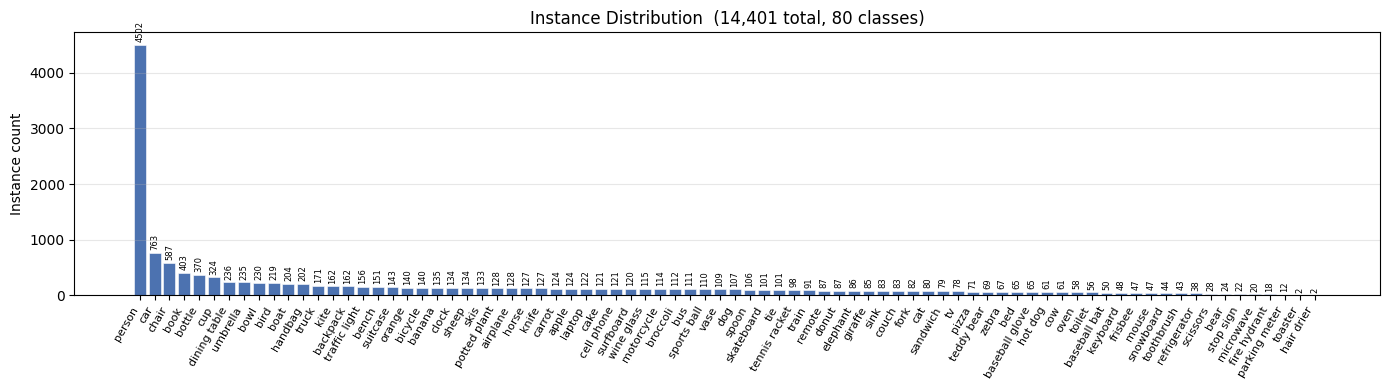

In [9]:
# distribution ของ instance แต่ละ class
from collections import Counter

instance_counts = Counter()
for img_id in tqdm(all_ids, desc='counting', leave=False):
    for ann in coco_api.loadAnns(coco_api.getAnnIds(imgIds=img_id, iscrowd=False)):
        instance_counts[CAT_MAP[ann['category_id']]] += 1

indices = sorted(instance_counts, key=instance_counts.get, reverse=True)
names   = [CAT_NAMES[i] for i in indices]
counts  = [instance_counts[i] for i in indices]

fig, ax = plt.subplots(figsize=(14, 4))
bars = ax.bar(range(len(names)), counts, color='#4C72B0', edgecolor='white', linewidth=0.4)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Instance count')
ax.set_title(f'Instance Distribution  ({sum(counts):,} total, {NUM_CLASSES} classes)')
ax.bar_label(bars, fmt='%d', padding=2, fontsize=6, rotation=90)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 5 · แบ่ง Train / Val / Test Split

In [10]:
random.shuffle(all_ids)

n_train   = int(len(all_ids) * TRAIN_RATIO)
n_val     = int(len(all_ids) * VAL_RATIO)

train_ids = all_ids[:n_train]
val_ids   = all_ids[n_train : n_train + n_val]
test_ids  = all_ids[n_train + n_val :]

splits    = {'train': train_ids, 'val': val_ids, 'test': test_ids}

for k, v in splits.items():
    print(f'{k:5s} : {len(v):,} images')

train : 1,400 images
val   : 300 images
test  : 300 images


## Step 6 · Helper Functions

- `mask_to_polygon_line` — แปลง binary mask เป็น YOLO polygon string
- `bbox_iou_with_mask` — คำนวณ IoU ระหว่าง SAM2 mask กับ GT bbox rectangle

In [11]:
def mask_to_polygon_line(mask: np.ndarray, cls: int, W: int, H: int) -> str | None:
    cnts, _ = cv2.findContours(
        mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not cnts:
        return None
    c = max(cnts, key=cv2.contourArea).squeeze()
    if c.ndim < 2 or len(c) < 3:
        return None
    c = c.astype(np.float32)
    c[:, 0] /= W
    c[:, 1] /= H
    return f'{cls} ' + ' '.join(f'{v:.6f}' for v in c.flatten())


def bbox_iou_with_mask(mask: np.ndarray, x1: int, y1: int, x2: int, y2: int) -> float:
    """IoU ระหว่าง SAM2 mask กับ GT bbox — ใช้เลือก mask ที่ดีที่สุดจาก 3 candidates"""
    H, W   = mask.shape
    bbox_m = np.zeros((H, W), dtype=bool)
    bbox_m[max(0,y1):min(H,y2), max(0,x1):min(W,x2)] = True
    inter  = (mask & bbox_m).sum()
    union  = (mask | bbox_m).sum()
    return float(inter) / float(union + 1e-6)


print('helpers ready')

helpers ready


## Step 7 · SAM2 Inference (ทุก Split)

รัน SAM2 บน **train / val / test** ทั้งหมด  
ใช้ GT bounding box เป็น prompt → เลือก mask ที่มี IoU กับ bbox สูงสุด → กำหนด class จาก GT

In [12]:
import torch
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

device    = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
sam2      = build_sam2(SAM2_CFG, SAM2_CKPT, device=device)
predictor = SAM2ImagePredictor(sam2)

print(f'SAM2 on {device}')

SAM2 on cuda:0


In [13]:
# สร้าง directories
EXP = DATA_ROOT / 'sam2_dataset'
for split in ['train', 'val', 'test']:
    (EXP / split / 'images').mkdir(parents=True, exist_ok=True)
    (EXP / split / 'labels').mkdir(parents=True, exist_ok=True)
print('directories created')

directories created


In [14]:
def run_sam2_on_split(img_ids: list, split: str) -> dict:
    img_dir = EXP / split / 'images'
    lbl_dir = EXP / split / 'labels'
    stats   = {'imgs': 0, 'anns': 0, 'kept': 0, 'skipped_iou': 0}

    for img_id in tqdm(img_ids, desc=f'SAM2 [{split}]'):
        info = coco_api.loadImgs(img_id)[0]
        src  = COCO_IMG_DIR / info['file_name']
        if not src.exists():
            continue

        image = cv2.cvtColor(cv2.imread(str(src)), cv2.COLOR_BGR2RGB)
        H, W  = image.shape[:2]
        stem  = Path(info['file_name']).stem

        ann_ids = coco_api.getAnnIds(imgIds=img_id, iscrowd=False)
        anns    = coco_api.loadAnns(ann_ids)

        shutil.copy2(src, img_dir / info['file_name'])

        if not anns:
            (lbl_dir / f'{stem}.txt').write_text('')
            continue

        predictor.set_image(image)   # encode ครั้งเดียวต่อภาพ

        lines = []
        for ann in anns:
            stats['anns'] += 1
            xywh = ann['bbox']
            bx1, by1 = int(xywh[0]), int(xywh[1])
            bx2, by2 = int(xywh[0] + xywh[2]), int(xywh[1] + xywh[3])

            box = np.array([[bx1, by1, bx2, by2]], dtype=np.float32)
            masks, _, _ = predictor.predict(box=box, multimask_output=True)

            # เลือก mask ที่มี IoU กับ GT bbox สูงสุด
            best_mask, best_iou = None, -1.0
            for m in masks:
                iou = bbox_iou_with_mask(m.astype(bool), bx1, by1, bx2, by2)
                if iou > best_iou:
                    best_iou, best_mask = iou, m

            if best_iou < MIN_MASK_IOU:
                stats['skipped_iou'] += 1
                continue

            cls  = CAT_MAP[ann['category_id']]
            line = mask_to_polygon_line(best_mask.astype(np.uint8), cls, W, H)
            if line:
                lines.append(line)
                stats['kept'] += 1

        (lbl_dir / f'{stem}.txt').write_text('\n'.join(lines))
        stats['imgs'] += 1

    return stats


all_stats = {}
for split, ids in splits.items():
    all_stats[split] = run_sam2_on_split(ids, split)

print('\nSAM2 Inference Summary:')
print(f'{"split":8s} {"imgs":>6} {"anns":>8} {"kept":>8} {"keep%":>8}')
for split, s in all_stats.items():
    pct = s['kept'] / max(s['anns'], 1) * 100
    print(f'{split:8s} {s["imgs"]:>6,} {s["anns"]:>8,} {s["kept"]:>8,} {pct:>7.1f}%')

SAM2 [train]:   0%|          | 0/1400 [00:00<?, ?it/s]

SAM2 [val]:   0%|          | 0/300 [00:00<?, ?it/s]

SAM2 [test]:   0%|          | 0/300 [00:00<?, ?it/s]


SAM2 Inference Summary:
split      imgs     anns     kept    keep%
train     1,385   10,153    9,719    95.7%
val         297    2,075    1,990    95.9%
test        295    2,173    2,061    94.8%


## Step 8 · Sanity Check — GT bbox vs SAM2 Mask

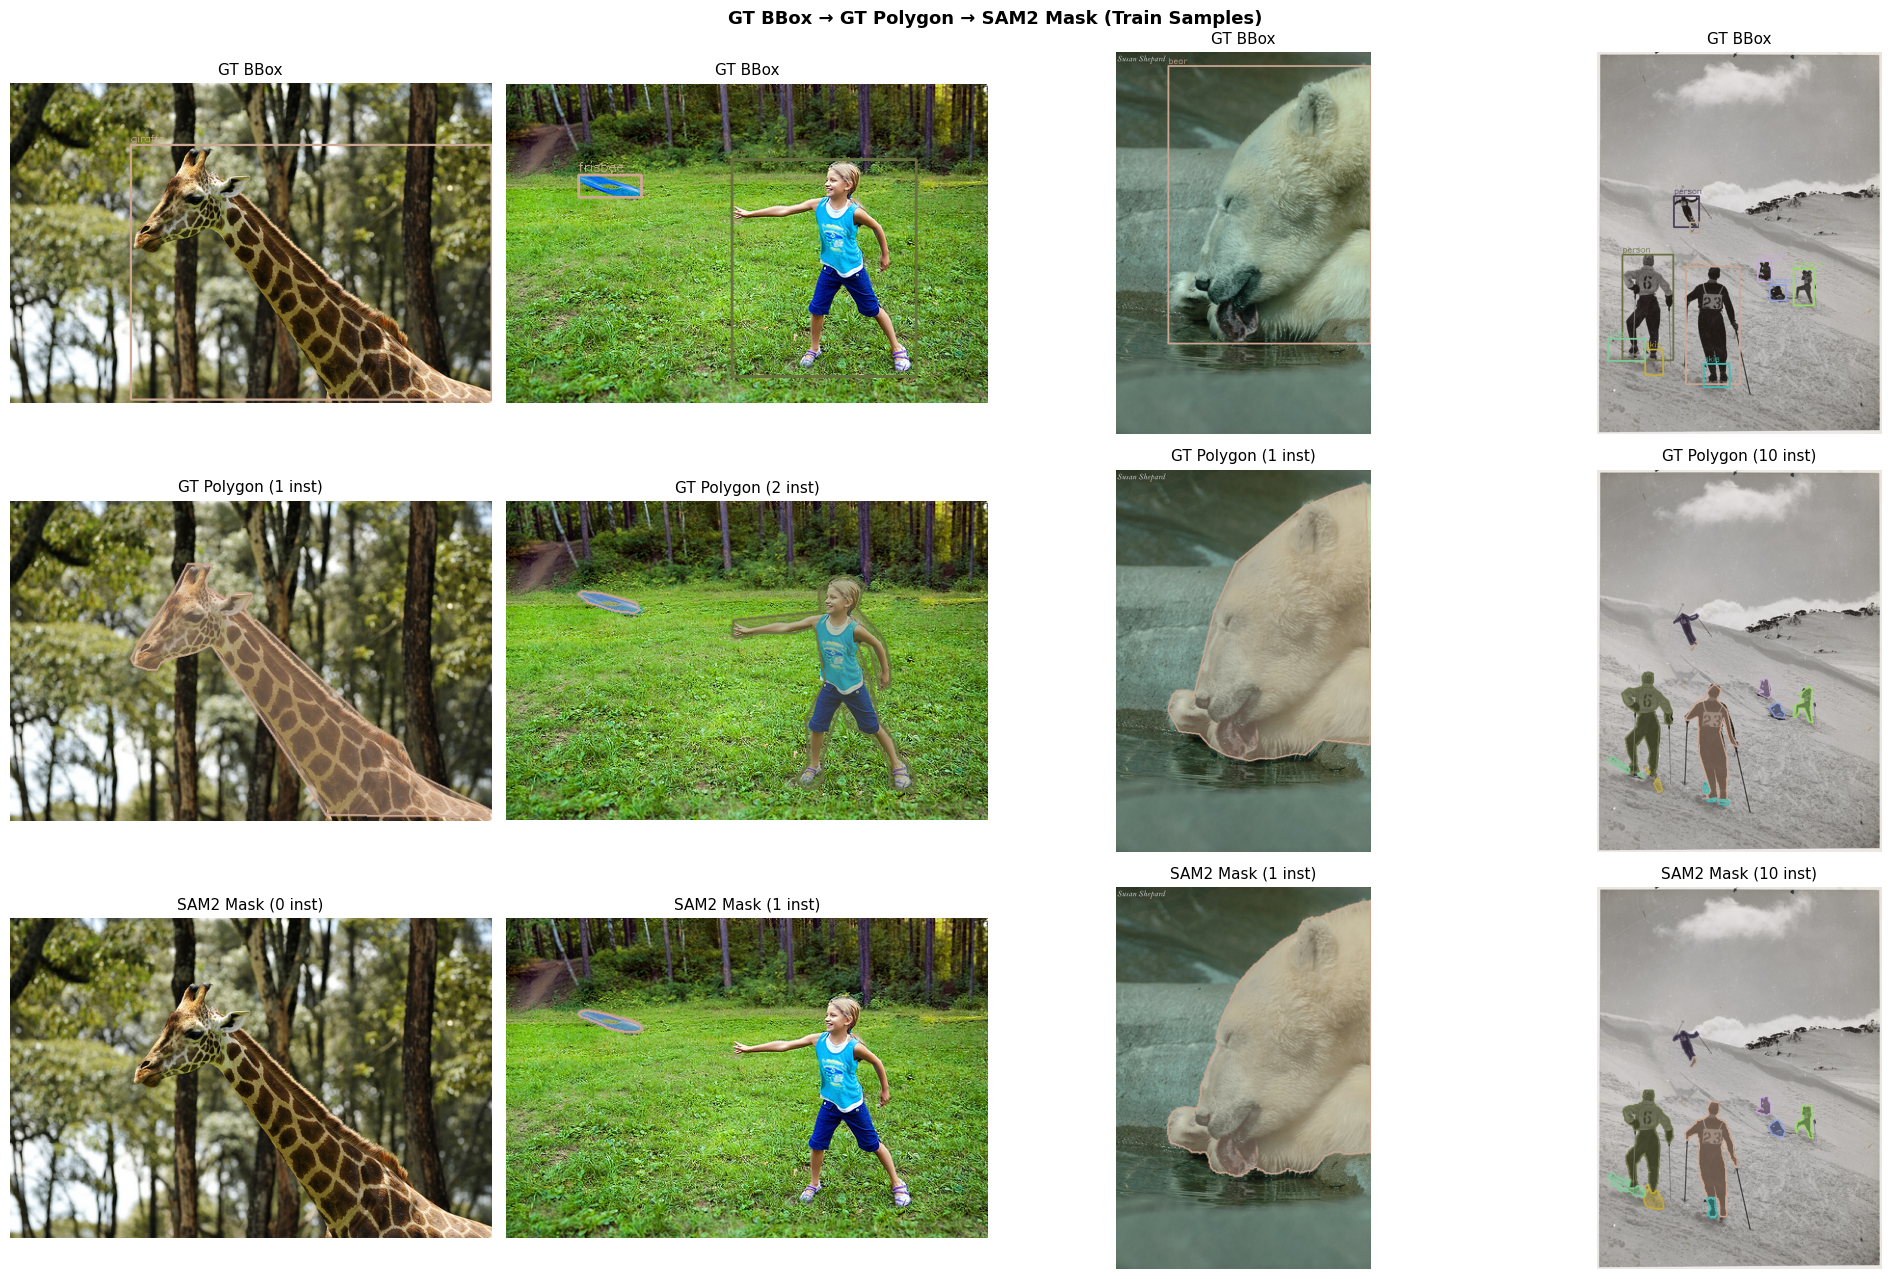

In [24]:
def draw_bboxes(img_path: Path, img_id: int) -> np.ndarray:
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    rng = np.random.default_rng(0)
    for ann in coco_api.loadAnns(coco_api.getAnnIds(imgIds=img_id, iscrowd=False)):
        x, y, w, h = ann['bbox']
        color = tuple(rng.integers(60, 230, 3).tolist())
        cv2.rectangle(img, (int(x), int(y)), (int(x+w), int(y+h)), color, 2)
        label = CAT_NAMES[CAT_MAP[ann['category_id']]]
        cv2.putText(img, label, (int(x), int(y)-4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)
    return img


def draw_gt_polygons(img_path: Path, img_id: int, alpha=0.45) -> np.ndarray:
    img     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    overlay = img.copy()
    H, W    = img.shape[:2]
    rng     = np.random.default_rng(0)
    for ann in coco_api.loadAnns(coco_api.getAnnIds(imgIds=img_id, iscrowd=False)):
        seg   = ann.get('segmentation', [])
        color = tuple(rng.integers(60, 230, 3).tolist())
        if isinstance(seg, dict):                          # RLE
            m = maskUtils.decode(maskUtils.frPyObjects(seg, H, W)).squeeze()
            cnts, _ = cv2.findContours(m.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            for c in cnts:
                cv2.fillPoly(overlay, [c], color)
                cv2.polylines(img, [c], True, color, 2)
        else:
            for poly in seg:
                pts = np.array(poly, dtype=np.float32).reshape(-1, 2).astype(np.int32)
                cv2.fillPoly(overlay, [pts], color)
                cv2.polylines(img, [pts], True, color, 2)
    return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)


def draw_sam2_masks(img_path: Path, lbl_path: Path, alpha=0.45) -> np.ndarray:
    img     = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    overlay = img.copy()
    H, W    = img.shape[:2]
    rng     = np.random.default_rng(0)
    if lbl_path.exists():
        for line in lbl_path.read_text().splitlines():
            parts = line.strip().split()
            if len(parts) < 7: continue
            pts = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
            pts[:, 0] *= W; pts[:, 1] *= H
            color = tuple(rng.integers(60, 230, 3).tolist())
            cv2.fillPoly(overlay, [pts.astype(np.int32)], color)
            cv2.polylines(img, [pts.astype(np.int32)], True, color, 2)
    return cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)


# แสดง 4 ตัวอย่างจาก train set
sample_ids = [
    i for i in train_ids[:20]
    if (COCO_IMG_DIR / coco_api.loadImgs(i)[0]['file_name']).exists()
][:4]

fig, axes = plt.subplots(3, len(sample_ids), figsize=(5 * len(sample_ids), 13))

for col, img_id in enumerate(sample_ids):
    info  = coco_api.loadImgs(img_id)[0]
    stem  = Path(info['file_name']).stem
    fname = info['file_name']
    img_p = EXP / 'train' / 'images' / fname
    lbl_p = EXP / 'train' / 'labels' / f'{stem}.txt'

    axes[0][col].imshow(draw_bboxes(COCO_IMG_DIR / fname, img_id))
    axes[0][col].set_title('GT BBox', fontsize=11)
    axes[0][col].axis('off')

    axes[1][col].imshow(draw_gt_polygons(COCO_IMG_DIR / fname, img_id))
    n_gt = len(coco_api.getAnnIds(imgIds=img_id, iscrowd=False))
    axes[1][col].set_title(f'GT Polygon ({n_gt} inst)', fontsize=11)
    axes[1][col].axis('off')

    axes[2][col].imshow(draw_sam2_masks(img_p, lbl_p))
    n_s2 = len(lbl_p.read_text().splitlines()) if lbl_p.exists() else 0
    axes[2][col].set_title(f'SAM2 Mask ({n_s2} inst)', fontsize=11)
    axes[2][col].axis('off')

plt.suptitle('GT BBox → GT Polygon → SAM2 Mask (Train Samples)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sanity_check.png', dpi=120, bbox_inches='tight')
plt.show()

จะเห็นได้ว่า SAM 2 สามารถ segment ได้ละเอียด โดยเฉพาะ object ที่ขอบชัดเจน แต่อาจตกหล่นได้ในภาพที่ object กลืนไปกับพื้นหลัง เมื่อเทียบกับ Polygonal ground truth ของ COCO ดังนั้นเราสามารถใช้ SAM 2 มาแปลงให้ Object detection dataset กลายเป็น instance segmentation dataset ที่คุณภาพดีได้

## Step 9 · สร้าง data.yaml สำหรับ YOLOv8

In [16]:
import yaml

yaml_path = EXP / 'data.yaml'
yaml_path.write_text(yaml.dump({
    'path'  : str(EXP.resolve()),
    'train' : 'train/images',
    'val'   : 'val/images',
    'test'  : 'test/images',
    'nc'    : NUM_CLASSES,
    'names' : CAT_NAMES,
}, allow_unicode=True))

print(yaml_path.read_text())

names:
- airplane
- apple
- backpack
- banana
- baseball bat
- baseball glove
- bear
- bed
- bench
- bicycle
- bird
- boat
- book
- bottle
- bowl
- broccoli
- bus
- cake
- car
- carrot
- cat
- cell phone
- chair
- clock
- couch
- cow
- cup
- dining table
- dog
- donut
- elephant
- fire hydrant
- fork
- frisbee
- giraffe
- hair drier
- handbag
- horse
- hot dog
- keyboard
- kite
- knife
- laptop
- microwave
- motorcycle
- mouse
- orange
- oven
- parking meter
- person
- pizza
- potted plant
- refrigerator
- remote
- sandwich
- scissors
- sheep
- sink
- skateboard
- skis
- snowboard
- spoon
- sports ball
- stop sign
- suitcase
- surfboard
- teddy bear
- tennis racket
- tie
- toaster
- toilet
- toothbrush
- traffic light
- train
- truck
- tv
- umbrella
- vase
- wine glass
- zebra
nc: 80
path: /content/dataset/sam2_dataset
test: test/images
train: train/images
val: val/images



## Step 10 · Train YOLOv8-seg

Train บน SAM2 masks (train split) และ monitor ด้วย SAM2 masks (val split)

In [17]:
from ultralytics import YOLO

model = YOLO(BASE_MODEL)
model.train(
    data     = str(yaml_path),
    name     = 'sam2_seg',
    project  = 'runs',
    imgsz    = IMG_SIZE,
    epochs   = EPOCHS,
    batch    = BATCH,
    device   = DEVICE,
    workers  = 4,
    seed     = SEED,
    verbose  = False,
    exist_ok = True,
)
print('✅ Training complete')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/sam2_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, img

## Step 11 · Training Curves

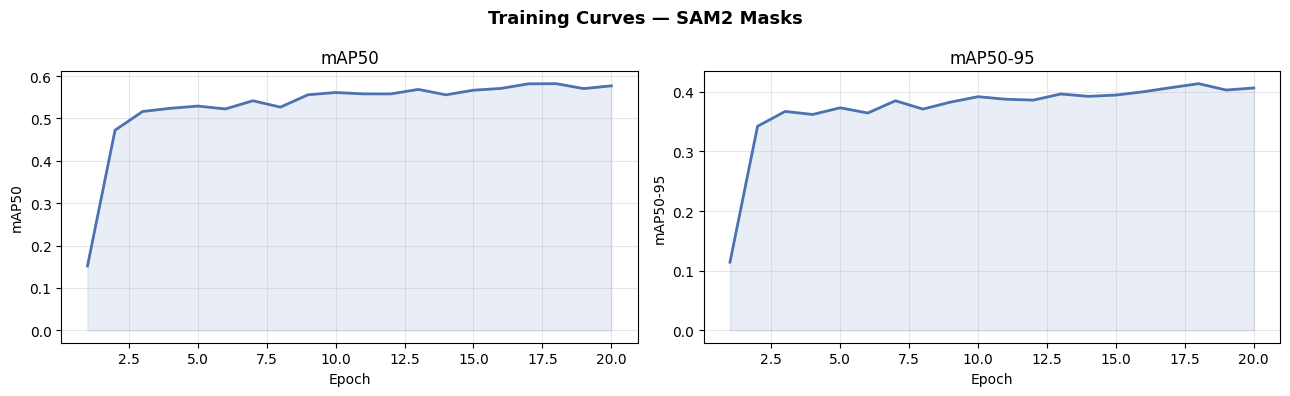

In [19]:
import pandas as pd

csv_path = Path('/content/runs/segment/runs/sam2_seg/results.csv')
df       = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
        ['metrics/mAP50(M)', 'metrics/mAP50-95(M)'],
        ['mAP50', 'mAP50-95']):
    if col in df.columns:
        ax.plot(df['epoch'], df[col], color='#4C72B0', lw=2)
        ax.fill_between(df['epoch'], df[col], alpha=0.12, color='#4C72B0')
    ax.set_xlabel('Epoch'); ax.set_ylabel(title); ax.set_title(title)
    ax.grid(alpha=0.3)

plt.suptitle('Training Curves — SAM2 Masks', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 · Evaluate บน Test Set

ประเมินผล model บน test split ที่ใช้ SAM2 masks เป็น reference

In [20]:
ckpt    = '/content/runs/segment/runs/sam2_seg/weights/best.pt'
metrics = YOLO(ckpt).val(
    data    = str(yaml_path),
    split   = 'test',
    imgsz   = IMG_SIZE,
    device  = DEVICE,
    verbose = False,
)

results = {
    'mAP50'    : metrics.seg.map50,
    'mAP50-95' : metrics.seg.map,
    'Precision': metrics.seg.mp,
    'Recall'   : metrics.seg.mr,
}

print('── Test Set Results ──────────────────')
for k, v in results.items():
    print(f'  {k:<12}: {v:.4f}')

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLOv8l-seg summary (fused): 126 layers, 45,973,568 parameters, 0 gradients, 210.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2168.9±898.3 MB/s, size: 157.6 KB)
val: Scanning /content/dataset/sam2_dataset/test/labels... 300 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 300/300 804.0it/s 0.4s
val: New cache created: /content/dataset/sam2_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 2.7it/s 7.1s
                   all        300       2061      0.748      0.565      0.651      0.512      0.746      0.549      0.626      0.443
Speed: 1.0ms preprocess, 14.5ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to /content/runs/segment/val
── Test Set Results ──────────────────
  mAP50       : 0.6265
  mAP50-95    : 0.4434
  Precision   :

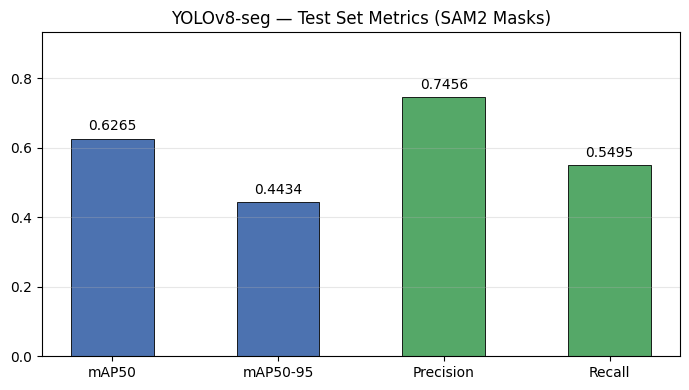

💾 results.csv saved


In [21]:
# แสดงผลเป็น bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(results.keys()), list(results.values()),
              color=['#4C72B0','#4C72B0','#55A868','#55A868'],
              edgecolor='black', linewidth=0.6, width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_ylim(0, max(results.values()) * 1.25)
ax.set_title('YOLOv8-seg — Test Set Metrics (SAM2 Masks)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results_bar.png', dpi=150, bbox_inches='tight')
plt.show()

import pandas as pd
pd.DataFrame([results]).T.rename(columns={0:'value'}).to_csv('results.csv')
print('💾 results.csv saved')

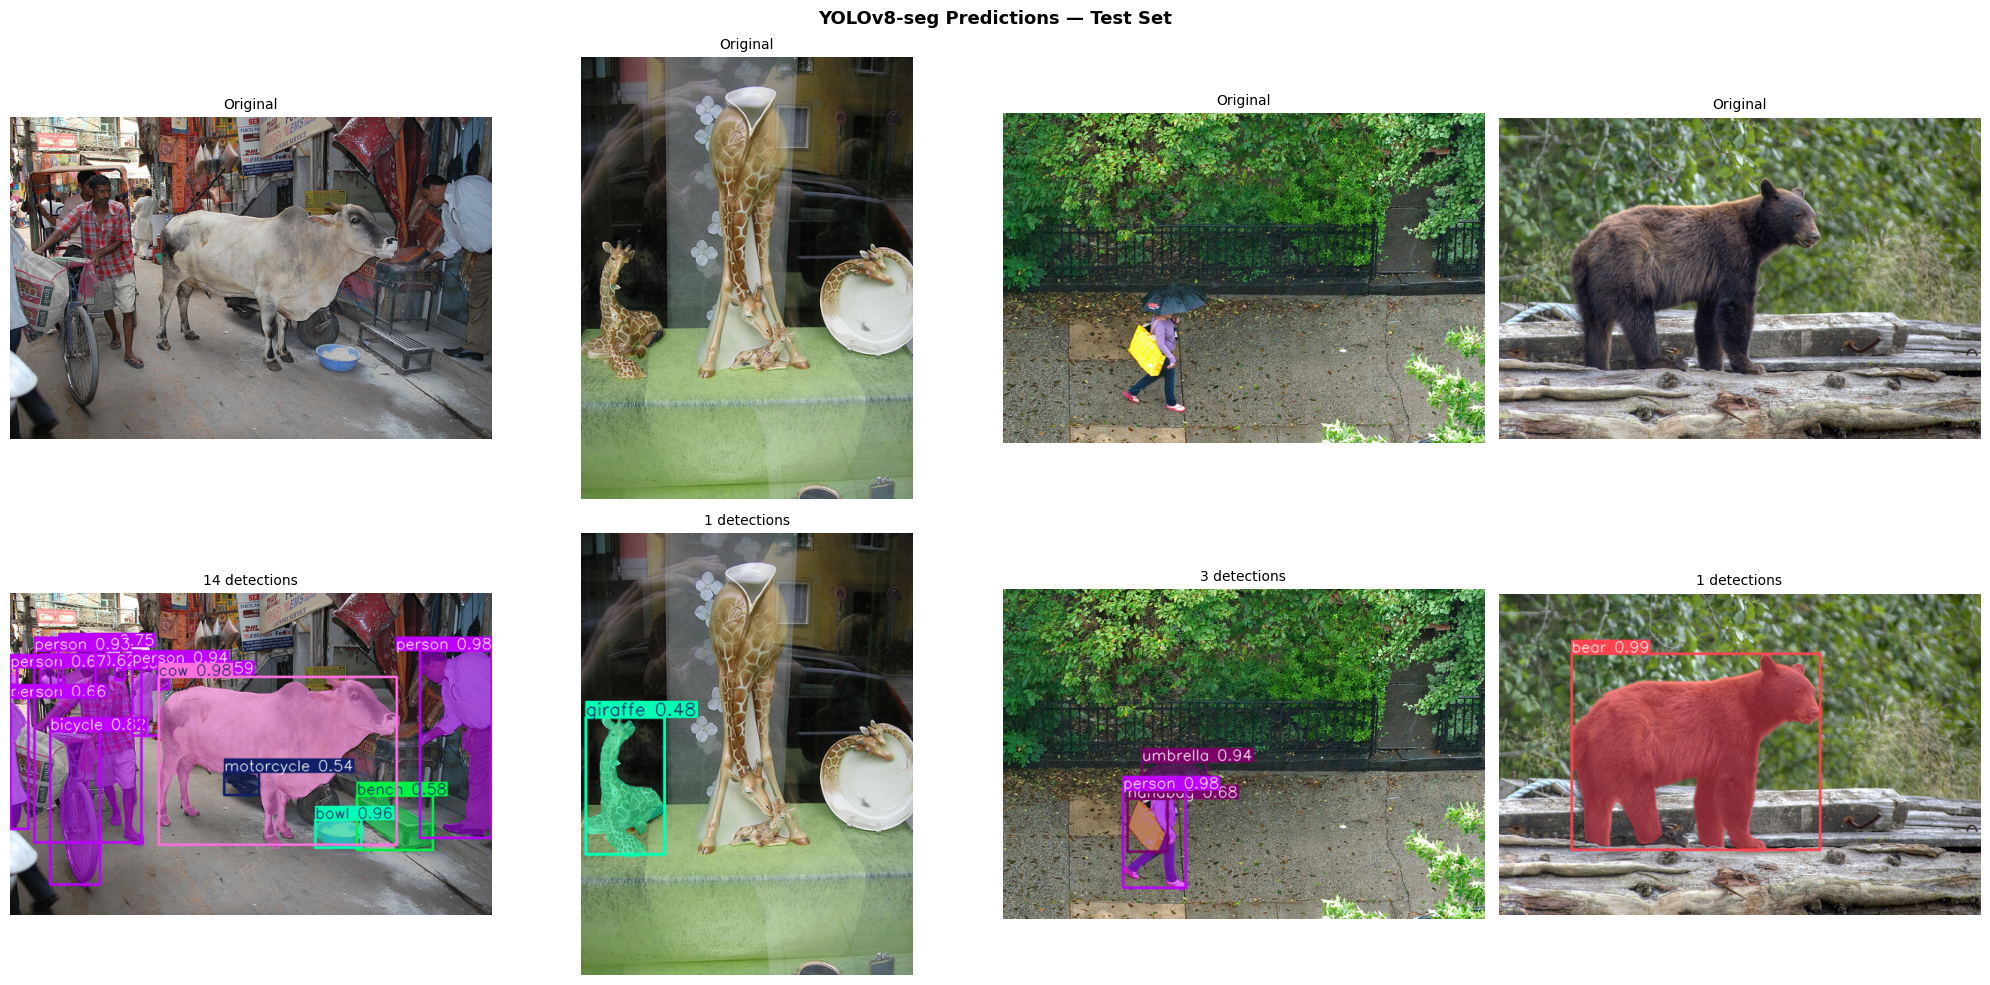

In [25]:
# เลือก 4 ภาพจาก test split
test_samples = [
    coco_api.loadImgs(i)[0] for i in test_ids[:20]
    if (EXP / 'test' / 'images' / coco_api.loadImgs(i)[0]['file_name']).exists()
][:4]

model_inf = YOLO(ckpt)

fig, axes = plt.subplots(2, len(test_samples), figsize=(5 * len(test_samples), 10))

for col, info in enumerate(test_samples):
    img_path = str(EXP / 'test' / 'images' / info['file_name'])

    # row 0: original
    orig = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    axes[0][col].imshow(orig)
    axes[0][col].set_title('Original', fontsize=10)
    axes[0][col].axis('off')

    # row 1: prediction
    res   = model_inf.predict(img_path, imgsz=IMG_SIZE, conf=0.25, verbose=False)[0]
    vis   = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    n_det = len(res.boxes) if res.boxes is not None else 0
    axes[1][col].imshow(vis)
    axes[1][col].set_title(f'{n_det} detections', fontsize=10)
    axes[1][col].axis('off')

plt.suptitle('YOLOv8-seg Predictions — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('predictions.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
print('=' * 52)
print('  SAM2 Box-Prompt → YOLOv8-seg  |  Summary')
print('=' * 52)
print(f'  Dataset          : COCO ({MAX_SAMPLES:,} images)')
print(f'  Split            : train={len(train_ids)} | val={len(val_ids)} | test={len(test_ids)}')
print(f'  Labels           : SAM2-generated masks (all splits)')
print(f'  Min mask IoU     : {MIN_MASK_IOU}')
print()
total_anns = sum(s['anns'] for s in all_stats.values())
total_kept = sum(s['kept'] for s in all_stats.values())
print(f'  Total annotations: {total_anns:,}')
print(f'  Masks kept       : {total_kept:,} ({total_kept/max(total_anns,1)*100:.1f}%)')
print()
print('  Test Results:')
for k, v in results.items():
    print(f'    {k:<12}: {v:.4f}')
print()
print('  Output files:')
for f in ['category_distribution.png', 'sanity_check.png',
          'training_curves.png', 'results_bar.png',
          'predictions.png', 'results.csv']:
    print(f'  {"✅" if Path(f).exists() else "❌"} {f}')
print('=' * 52)

  SAM2 Box-Prompt → YOLOv8-seg  |  Summary
  Dataset          : COCO (2,000 images)
  Split            : train=1400 | val=300 | test=300
  Labels           : SAM2-generated masks (all splits)
  Min mask IoU     : 0.3

  Total annotations: 14,401
  Masks kept       : 13,770 (95.6%)

  Test Results:
    mAP50       : 0.6265
    mAP50-95    : 0.4434
    Precision   : 0.7456
    Recall      : 0.5495

  Output files:
  ✅ category_distribution.png
  ✅ sanity_check.png
  ✅ training_curves.png
  ✅ results_bar.png
  ✅ predictions.png
  ✅ results.csv
